# 00 - Verificaciones sintéticas

Acá pruebo las herramientas con señales conocidas antes de usarlas con DroneRF. Lo hago bien paso a paso, como en las tareas: defino `fs`, `ts`, `N`, `df`, `tt` y `ff`, después calculo y recién ahí grafico.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from aps_drone_rf.config import (
    DATA_DIR,
    FEATURES_DIR,
    FIGURES_DIR,
    INTERIM_DATA_DIR,
    METRICS_DIR,
    TABLES_DIR,
    ensure_project_dirs,
)
from aps_drone_rf.plots import save_figure
from aps_drone_rf.estilo import (
    COLOR_SERIE,
    aplicar_estilo_matplotlib,
    color_clase,
    etiqueta_clase,
    nombre_clase,
)

ensure_project_dirs()
aplicar_estilo_matplotlib()
SEED = 42
rng = np.random.default_rng(SEED)
plt.rcParams["figure.figsize"] = (8, 3)
plt.rcParams["axes.grid"] = True


## Senoidal pura y eje frecuencial

Arranco con una senoidal simple. Como ya sé su frecuencia, la FFT debería marcar el pico cerca de ese valor. También miro la resolución `df = fs/N`.


fs = 2000.0 Hz, N = 2000, df = 1.000 Hz
Frecuencia esperada = 180.0 Hz
Frecuencia detectada = 180.0 Hz


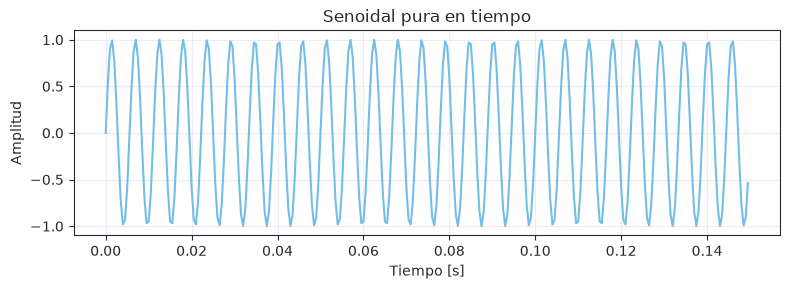

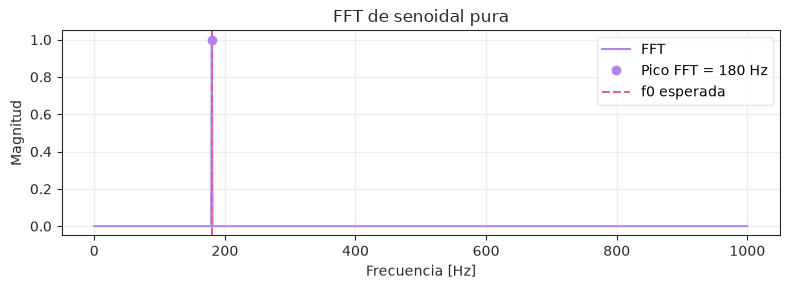

In [2]:
fs = 2_000.0
N = 2_000
ts = 1 / fs
df = fs / N

f0 = 180.0
A0 = 1.0

tt = np.linspace(0, (N - 1) * ts, N)
ff = np.linspace(0, fs / 2, N // 2 + 1)

xx = A0 * np.sin(2 * np.pi * f0 * tt)
XX = (1 / N) * np.fft.rfft(xx)
mag = 2 * np.abs(XX)
mag[0] = mag[0] / 2

f_detectada = ff[np.argmax(mag)]
print(f"fs = {fs:.1f} Hz, N = {N}, df = {df:.3f} Hz")
print(f"Frecuencia esperada = {f0:.1f} Hz")
print(f"Frecuencia detectada = {f_detectada:.1f} Hz")

fig, ax = plt.subplots()
ax.plot(tt[:300], xx[:300])
ax.set_title("Senoidal pura en tiempo")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud")
save_figure(fig, FIGURES_DIR / "nb00_senoidal_tiempo.png")
plt.show()

indice_pico = np.argmax(mag)
fig, ax = plt.subplots()
ax.plot(ff, mag, label="FFT", color=COLOR_SERIE["periodograma"])
ax.plot(
    ff[indice_pico], mag[indice_pico], "o", color=COLOR_SERIE["periodograma"],
    label=f"Pico FFT = {ff[indice_pico]:.0f} Hz", zorder=3
)
ax.axvline(f0, color=color_clase("dron"), linestyle="--", label="f0 esperada")
ax.set_title("FFT de senoidal pura")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Magnitud")
ax.legend()
save_figure(fig, FIGURES_DIR / "nb00_senoidal_fft.png")
plt.show()


## Suma de senoidales con ruido

Ahora mezclo dos tonos y ruido blanco. Esto se parece un poco más a una señal real, porque no todo aparece limpio.


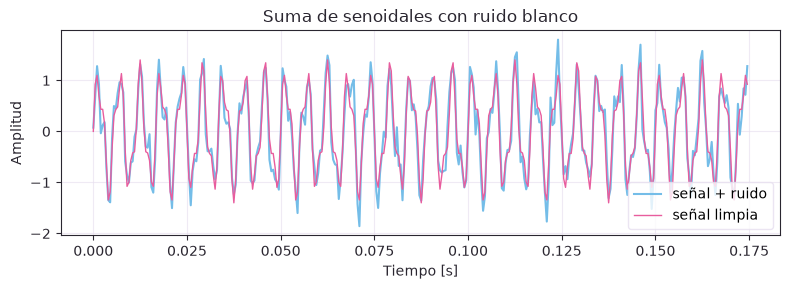

In [3]:
f1 = 180.0
f2 = 420.0
snr_db = 10.0

xx_limpia = np.sin(2 * np.pi * f1 * tt) + 0.4 * np.sin(2 * np.pi * f2 * tt)
pot_senal = np.mean(xx_limpia**2)
pot_ruido = pot_senal / (10 ** (snr_db / 10))
ruido = rng.normal(0, np.sqrt(pot_ruido), size=N)
xx_ruidosa = xx_limpia + ruido

fig, ax = plt.subplots()
ax.plot(tt[:350], xx_ruidosa[:350], label="señal + ruido")
ax.plot(tt[:350], xx_limpia[:350], linewidth=1, label="señal limpia")
ax.set_title("Suma de senoidales con ruido blanco")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud")
ax.legend()
save_figure(fig, FIGURES_DIR / "nb00_suma_senoidales_ruido.png")
plt.show()


## Periodograma vs Welch

Acá comparo dos formas de estimar la PSD. El periodograma sale más irregular; Welch promedia tramos y por eso suele quedar más estable.


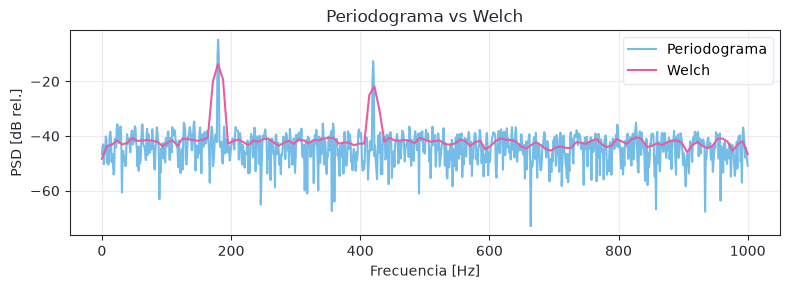

In [4]:
f_per, p_per = signal.periodogram(xx_ruidosa, fs=fs, window="hann", scaling="density")
f_welch, p_welch = signal.welch(
    xx_ruidosa,
    fs=fs,
    window="hann",
    nperseg=256,
    noverlap=128,
    scaling="density",
)

fig, ax = plt.subplots()
ax.plot(f_per, 10 * np.log10(np.maximum(p_per, 1e-20)), label="Periodograma")
ax.plot(f_welch, 10 * np.log10(np.maximum(p_welch, 1e-20)), label="Welch")
ax.set_title("Periodograma vs Welch")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("PSD [dB rel.]")
ax.legend()
save_figure(fig, FIGURES_DIR / "nb00_periodograma_vs_welch.png")
plt.show()


## Ventanas y fuga espectral

Pruebo qué pasa cuando la frecuencia no cae justo en un bin de la FFT. Ahí aparece fuga espectral, y por eso tiene sentido comparar ventanas.


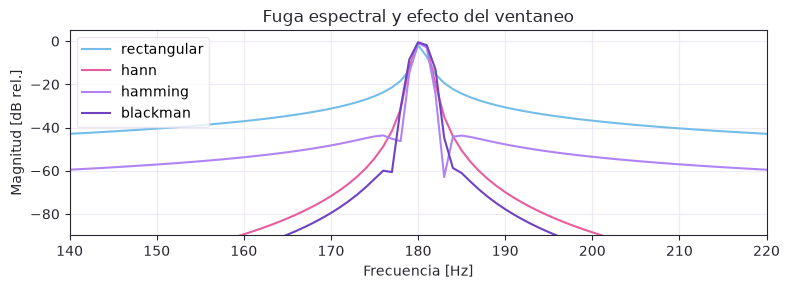

In [5]:
f_desintonizada = f0 + 0.35 * df
xx_des = np.sin(2 * np.pi * f_desintonizada * tt)
ventanas = {
    "rectangular": np.ones(N),
    "hann": signal.windows.hann(N, sym=False),
    "hamming": signal.windows.hamming(N, sym=False),
    "blackman": signal.windows.blackman(N, sym=False),
}

fig, ax = plt.subplots()
for nombre, ww in ventanas.items():
    XXw = (1 / N) * np.fft.rfft(xx_des * ww)
    magw = 2 * np.abs(XXw) / max(np.mean(ww), 1e-12)
    ax.plot(ff, 20 * np.log10(np.maximum(magw, 1e-12)), label=nombre)

ax.set_xlim(f0 - 40, f0 + 40)
ax.set_ylim(-90, 5)
ax.set_title("Fuga espectral y efecto del ventaneo")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Magnitud [dB rel.]")
ax.legend()
save_figure(fig, FIGURES_DIR / "nb00_ventanas_fuga_espectral.png")
plt.show()


## Modulación AM simple

Uso una AM simple solo como ejemplo de apoyo. Me sirve para ver cómo aparecen componentes alrededor de una portadora.


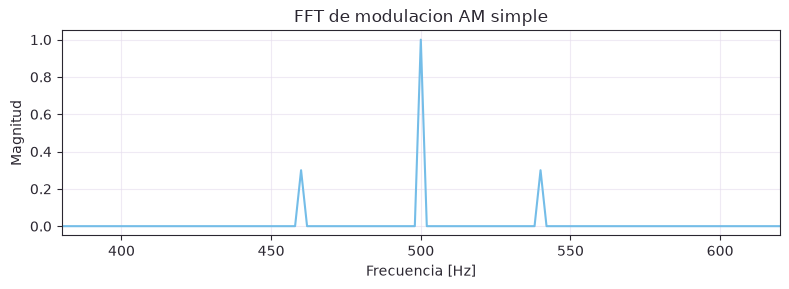

In [6]:
fc = 500.0
fm = 40.0
m = 0.6
xx_am = (1 + m * np.sin(2 * np.pi * fm * tt)) * np.sin(2 * np.pi * fc * tt)
XX_am = (1 / N) * np.fft.rfft(xx_am * signal.windows.hann(N, sym=False))
mag_am = 2 * np.abs(XX_am) / np.mean(signal.windows.hann(N, sym=False))

fig, ax = plt.subplots()
ax.plot(ff, mag_am)
ax.set_xlim(fc - 120, fc + 120)
ax.set_title("FFT de modulacion AM simple")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Magnitud")
save_figure(fig, FIGURES_DIR / "nb00_am_fft.png")
plt.show()


## Cuantización

Acá bajo la cantidad de bits para ver cómo aumenta el error. No es el centro del trabajo, pero sirve como sensibilidad secundaria.


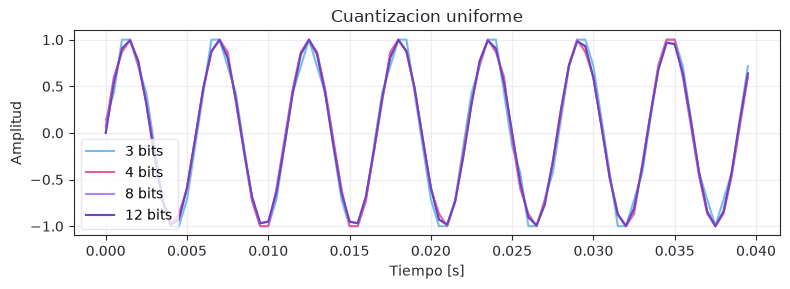

,bits,mse,max_error
0,3,5.899996e-03,0.142857
1,4,1.379052e-03,0.066667
2,8,5.037797e-06,0.003922
3,12,1.176894e-08,0.000244


In [7]:
filas = []
fig, ax = plt.subplots()
for bits in [3, 4, 8, 12]:
    niveles = 2**bits
    x_clip = np.clip(xx, -1, 1)
    xq = np.round((x_clip + 1) * (niveles - 1) / 2)
    xq = (2 * xq / (niveles - 1)) - 1
    err = xx - xq
    filas.append({"bits": bits, "mse": np.mean(err**2), "max_error": np.max(np.abs(err))})
    ax.plot(tt[:80], xq[:80], label=f"{bits} bits")

ax.set_title("Cuantizacion uniforme")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud")
ax.legend()
save_figure(fig, FIGURES_DIR / "nb00_cuantizacion.png")
plt.show()

tabla_cuantizacion = pd.DataFrame(filas)
tabla_cuantizacion.to_csv(TABLES_DIR / "nb00_cuantizacion.csv", index=False)
display(tabla_cuantizacion)
